<a href="https://colab.research.google.com/github/NikethnaSri-AI/Aanseaa_Technologies_Internship/blob/main/character_level_transformer_spelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('final.csv')
print(f"Loaded {len(df)} rows of data.")
print(df.head())


Loaded 21571 rows of data.
  Misspelling Corrected Unnamed: 2
0      strang     range        NaN
1       brake     break        NaN
2       brack     break        NaN
3     weanter    winter        NaN
4        gost     ghost        NaN


In [ ]:
# Step 1: Drop columns that contain only NaN values
df = df.dropna(axis=1, how='all')

# Step 2: Drop columns whose names start with 'Unnamed'
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Step 3: Save the cleaned DataFrame to a new CSV file
df.to_csv("final.csv", index=False)



In [ ]:
df.isnull().values.any()


True

In [ ]:
df.dropna(inplace=True)

In [ ]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)
df.drop_duplicates(inplace=True)

1133


In [ ]:
print(df.head())

  Misspelling Corrected
0      strang     range
1       brake     break
2       brack     break
3     weanter    winter
4        gost     ghost


In [ ]:
# Assuming your DataFrame is named 'df' and has columns 'Misspelling' and 'Corrected'
df['Misspelling_word_count'] = df['Misspelling'].str.split().str.len()
df['Corrected_word_count'] = df['Corrected'].str.split().str.len()

print(f"Total words in 'Misspelling' column: {df['Misspelling_word_count'].sum()}")
print(f"Total words in 'Corrected' column: {df['Corrected_word_count'].sum()}")

Total words in 'Misspelling' column: 20427
Total words in 'Corrected' column: 20427


In [ ]:
print

In [ ]:
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(df['Misspelling'].tolist() + df['Corrected'].tolist())
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")

# Convert the misspelled and corrected words to sequences of integers
X = tokenizer.texts_to_sequences(df['Misspelling'].tolist())
y = tokenizer.texts_to_sequences(df['Corrected'].tolist())

# Pad sequences to ensure uniform input length
max_length = 20
X_pad = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')
y_pad = pad_sequences(y, maxlen=max_len, padding='post', truncating='post')


Vocabulary size: 32


In [ ]:
tokenizer.word_index

{'e': 1,
 ' ': 2,
 'i': 3,
 'n': 4,
 'a': 5,
 't': 6,
 'o': 7,
 's': 8,
 'r': 9,
 'c': 10,
 'l': 11,
 'u': 12,
 'm': 13,
 'd': 14,
 'p': 15,
 'y': 16,
 'g': 17,
 'h': 18,
 'f': 19,
 'v': 20,
 'b': 21,
 'k': 22,
 'w': 23,
 'q': 24,
 'x': 25,
 'z': 26,
 'j': 27,
 "'": 28,
 '_': 29,
 '.': 30,
 '-': 31}

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_pad, y_pad, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

# Print dataset shapes
print(f"Training set: X_train.shape={X_train.shape}, y_train.shape={y_train.shape}")
print(f"Validation set: X_val.shape={X_val.shape}, y_val.shape={y_val.shape}")
print(f"Test set: X_test.shape={X_test.shape}, y_test.shape={y_test.shape}")


Training set: X_train.shape=(16545, 20), y_train.shape=(16545, 20)
Validation set: X_val.shape=(1839, 20), y_val.shape=(1839, 20)
Test set: X_test.shape=(2043, 20), y_test.shape=(2043, 20)


In [ ]:
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model) // 2)) / d_model)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)


In [ ]:
inputs = layers.Input(shape=(max_length,))
embedding_layer = layers.Embedding(vocab_size, 128)(inputs)  # Embedding layer

# Add positional encoding to the embeddings
pos_encoding = positional_encoding(max_length, 128)
embedding_layer = embedding_layer + pos_encoding

# Dropout after embedding
embedding_layer = layers.Dropout(0.2)(embedding_layer)

# Multi-Head Attention Layer
attention_layer = layers.MultiHeadAttention(num_heads=8, key_dim=128)(embedding_layer, embedding_layer)
attention_layer = layers.Dropout(0.2)(attention_layer)
attention_layer = layers.LayerNormalization(epsilon=1e-6)(embedding_layer + attention_layer)  # Skip connection

# Feedforward Network
ffn_layer = layers.Dense(512, activation='relu')(attention_layer)
ffn_layer = layers.Dropout(0.2)(ffn_layer)
ffn_layer = layers.Dense(128)(ffn_layer)

# Add a second layer normalization (as in the original Transformer)
output_layer = layers.LayerNormalization(epsilon=1e-6)(attention_layer + ffn_layer)

# Final Dense Layer to predict each character in the output sequence
outputs = layers.Dense(vocab_size, activation='softmax')(output_layer)

# Model setup
model = models.Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,  # Training data
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),  # Explicit validation data
    callbacks=[early_stopping]  # Early stopping callback
)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/nn.py:635: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


518/518 ━━━━━━━━━━━━━━━━━━━━ 85s 158ms/step - accuracy: 0.5400 - loss: 1.8506 - val_accuracy: 0.6141 - val_loss: 1.3139
Epoch 2/30
518/518 ━━━━━━━━━━━━━━━━━━━━ 144s 162ms/step - accuracy: 0.6070 - loss: 1.3403 - val_accuracy: 0.6178 - val_loss: 1.2949
Epoch 3/30
518/518 ━━━━━━━━━━━━━━━━━━━━ 138s 154ms/step - accuracy: 0.6131 - loss: 1.3149 - val_accuracy: 0.6219 - val_loss: 1.2765
Epoch 4/30
518/518 ━━━━━━━━━━━━━━━━━━━━ 82s 154ms/step - accuracy: 0.6214 - loss: 1.2865 - val_accuracy: 0.6361 - val_loss: 1.2239
Epoch 5/30
518/518 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 0.6426 - loss: 1.2206 - val_accuracy: 0.7104 - val_loss: 0.9821
Epoch 6/30
518/518 ━━━━━━━━━━━━━━━━━━━━ 83s 156ms/step - accuracy: 0.7066 - loss: 1.0068 - val_accuracy: 0.7640 - val_loss: 0.8163
Epoch 7/30
518/518 ━━━━━━━━━━━━━━━━━━━━ 81s 157ms/step - accuracy: 0.7355 - loss: 0.9047 - val_accuracy: 0.7726 - val_loss: 0.7772
Epoch 8/30
518/518 ━━━━━━━━━━━━━━━━━━━━ 81s 157ms/step - accuracy: 0.7468 - loss: 0.8593 - v

In [ ]:
# After training, evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.7998 - loss: 0.6266
Test Loss: 0.6273608207702637
Test Accuracy: 0.800636351108551


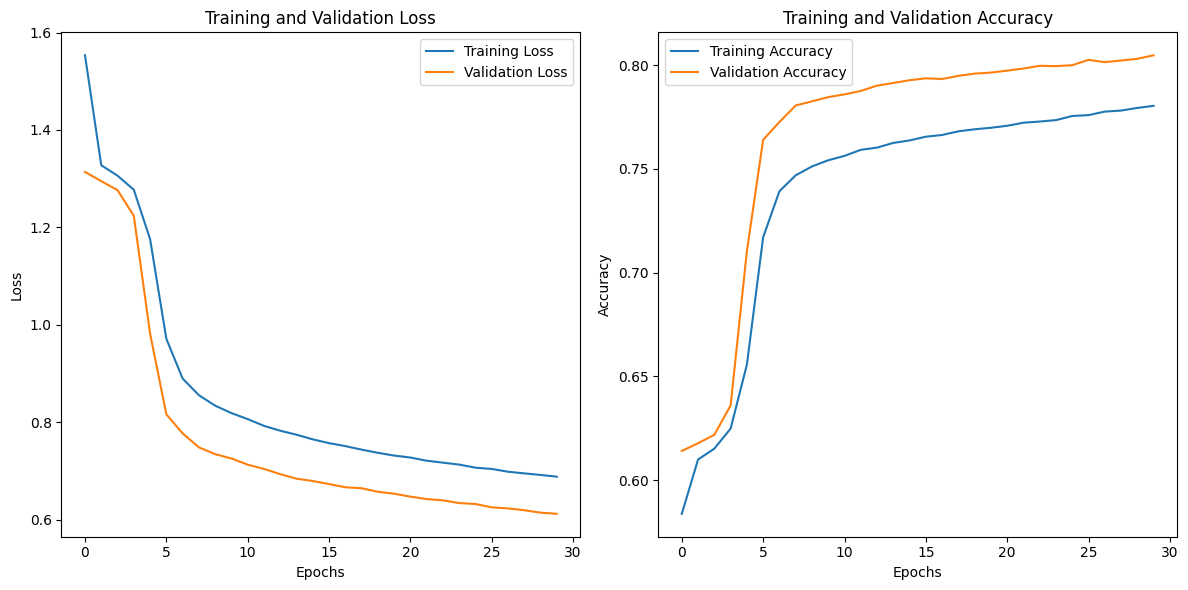

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.7998 - loss: 0.6266
Test Loss: 0.6273608207702637
Test Accuracy: 0.800636351108551


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import gradio as gr

In [ ]:
def predict_spelling_correction(misspelled_word, model, tokenizer, max_length):
    input_sequence = tokenizer.texts_to_sequences([misspelled_word])
    input_sequence = pad_sequences(input_sequence, maxlen=max_length, padding='post')
    predictions = model.predict(input_sequence)
    predicted_indices = tf.argmax(predictions, axis=-1).numpy()[0]
    corrected_word = ''.join([tokenizer.index_word[idx] for idx in predicted_indices if idx > 0])

    return corrected_word.strip()
user_input = input("Enter a misspelled word: ").strip()

corrected_spelling = predict_spelling_correction(user_input, model, tokenizer, max_length)

print(f"Corrected spelling: {corrected_spelling}")

Enter a misspelled word: gost
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
Corrected spelling: gost


In [ ]:
model.save('spelling_correction_model.h5')

In [ ]:
from google.colab import files
files.download('spelling_correction_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
def gradio_predict(misspelled_word):
    return predict_spelling_correction(misspelled_word, model, tokenizer, max_length)

In [ ]:
interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(label="Enter a Misspelled Word"),
    outputs=gr.Textbox(label="Corrected Spelling"),
    title="Spelling Correction Model",
    description="Enter a misspelled word, and the model will correct it for you."
)

interface.launch(debug=True)

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1ee4cfd552f409b9b1.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

In [ ]:
print(df.head(30))

   Misspelling    Corrected
0       strang        range
1        brake        break
2        brack        break
3      weanter       winter
4         gost        ghost
5       expect       except
6       steped      stepped
7      streagh      strange
8        colow     coloured
9    exclation    escalator
10      noicey      noticed
11       fance        fence
12       kille         kill
13      nerrow        arrow
14        depe         deep
15      gardon       garden
16        belu         blew
17      angray        angry
18       leavs       leaves
19      manger      manager
20        aero        arrow
21      ansion      ancient
22        dear         deer
23         flu         flew
24       noice        noise
25     stright     straight
26       menes        means
27      waight        waits
28        arow        arrow
29        dick          dig
